# 📡👥📱Customer Churn Analysis in Telecom Using Behavioral Data

### 🎯 Objetivo

El objetivo de este análisis es identificar patrones de comportamiento que permitan detectar clientes con alto riesgo de abandono (churn) en una empresa de telecomunicaciones.

Se busca construir variables que capturen señales tempranas de churn y desarrollar un modelo predictivo que permita anticipar estos casos.

In [212]:
# 📦 Librerías
import pandas as pds
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, classification_report


In [213]:
# Cargar el dataset
df = pds.read_csv("../data/telecom_churn_data.csv")

df.head()

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,...,0,1.0,1.0,1.0,NaN,968,30.4,0.0,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.0,0.0,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.0,0.0,4.17,0.00
3,7001204172,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,221.338,...,0,NaN,NaN,NaN,NaN,2491,0.0,0.0,0.00,0.00
4,7000142493,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,261.636,...,0,0.0,NaN,NaN,NaN,1526,0.0,0.0,0.00,0.00


### 🧹 Limpieza de datos 

In [214]:
# Tipo de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Columns: 226 entries, mobile_number to sep_vbc_3g
dtypes: float64(179), int64(35), str(12)
memory usage: 172.4 MB


In [215]:
# tipos de datos por columna
df.dtypes

mobile_number       int64
circle_id           int64
loc_og_t2o_mou    float64
std_og_t2o_mou    float64
loc_ic_t2o_mou    float64
                   ...   
aon                 int64
aug_vbc_3g        float64
jul_vbc_3g        float64
jun_vbc_3g        float64
sep_vbc_3g        float64
Length: 226, dtype: object

In [216]:
# lista de columnas a conservar
cols_keep = [
    # 💰 Dinero
    "arpu_6", "arpu_7", "arpu_8", "arpu_9",
    "total_rech_amt_6", "total_rech_amt_7", "total_rech_amt_8", "total_rech_amt_9",
    
    # 📞 Uso
    "total_og_mou_6", "total_og_mou_7", "total_og_mou_8", "total_og_mou_9",
    "total_ic_mou_6", "total_ic_mou_7", "total_ic_mou_8", "total_ic_mou_9",
    
    # 📡 Datos móviles
    "vol_2g_mb_6", "vol_2g_mb_7", "vol_2g_mb_8", "vol_2g_mb_9",
    "vol_3g_mb_6", "vol_3g_mb_7", "vol_3g_mb_8", "vol_3g_mb_9",
    
    # 📆 Actividad
    "total_rech_num_6", "total_rech_num_7", "total_rech_num_8", "total_rech_num_9",
    "aon",
]

# Crear un nuevo DataFrame solo con esas columnas
df_filtrado = df[cols_keep]

# Verificar
print(df_filtrado.head())


    arpu_6   arpu_7   arpu_8   arpu_9  total_rech_amt_6  total_rech_amt_7  \
0  197.385  214.816  213.803   21.100               362               252   
1   34.047  355.074  268.321   86.285                74               384   
2  167.690  189.058  210.226  290.714               168               315   
3  221.338  251.102  508.054  389.500               230               310   
4  261.636  309.876  238.174  163.426               196               350   

   total_rech_amt_8  total_rech_amt_9  total_og_mou_6  total_og_mou_7  ...  \
0               252                 0            0.00            0.00  ...   
1               283               121           40.31          178.53  ...   
2               116               358          155.33          412.94  ...   
3               601               410          223.23          135.31  ...   
4               287               200          127.28          241.33  ...   

   vol_2g_mb_9  vol_3g_mb_6  vol_3g_mb_7  vol_3g_mb_8  vol_3g_mb_9  

In [217]:
# valores faltantes
df_filtrado.isnull().sum().sort_values(ascending=False)

arpu_6              0
total_ic_mou_9      0
total_rech_num_9    0
total_rech_num_8    0
total_rech_num_7    0
total_rech_num_6    0
vol_3g_mb_9         0
vol_3g_mb_8         0
vol_3g_mb_7         0
vol_3g_mb_6         0
vol_2g_mb_9         0
vol_2g_mb_8         0
vol_2g_mb_7         0
vol_2g_mb_6         0
total_ic_mou_8      0
arpu_7              0
total_ic_mou_7      0
total_ic_mou_6      0
total_og_mou_9      0
total_og_mou_8      0
total_og_mou_7      0
total_og_mou_6      0
total_rech_amt_9    0
total_rech_amt_8    0
total_rech_amt_7    0
total_rech_amt_6    0
arpu_9              0
arpu_8              0
aon                 0
dtype: int64

In [218]:
# registros duplicados
df_filtrado.duplicated().sum()

np.int64(0)

In [219]:
# estadísticas descriptivas
df_filtrado.describe()

,arpu_6,arpu_7,arpu_8,arpu_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,total_og_mou_6,total_og_mou_7,...,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,aon
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,...,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,282.987358,278.536648,279.154731,261.645069,327.514615,322.962970,324.157122,303.345673,305.133424,310.231175,...,44.719701,121.396219,128.995847,135.410689,136.056613,7.558806,7.700367,7.212912,6.893019,1219.854749
std,328.439770,338.156291,344.474791,341.998630,398.019701,408.114237,416.540455,404.588583,463.419481,480.031178,...,198.653570,544.247227,541.494013,558.775335,577.394194,7.078405,7.070422,7.203753,7.096261,954.733842
min,-2258.709000,-2014.045000,-945.808000,-1899.505000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000
25%,93.411500,86.980500,84.126000,62.685000,109.000000,100.000000,90.000000,52.000000,44.740000,43.010000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,467.000000
50%,197.704000,191.640000,192.080000,176.849000,230.000000,220.000000,225.000000,200.000000,145.140000,141.530000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,6.000000,5.000000,5.000000,863.000000
75%,371.060000,365.344500,369.370500,353.466500,437.500000,428.000000,434.500000,415.000000,372.860000,378.570000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,10.000000,9.000000,9.000000,1807.500000
max,27731.088000,35145.834000,33543.624000,38805.617000,35190.000000,40335.000000,45320.000000,37235.000000,10674.030000,11365.310000,...,8993.950000,45735.400000,28144.120000,30036.060000,39221.270000,307.000000,138.000000,196.000000,131.000000,4337.000000


### 📈 EDA (análisis)

In [220]:
# definir churn en base a actividad del noveno mes
df_filtrado['churn'] = (
    (df_filtrado['total_rech_amt_9'] == 0) &
    (df_filtrado['total_og_mou_9'] == 0) &
    (df_filtrado['total_ic_mou_9'] == 0) &
    (df_filtrado['vol_2g_mb_9'] == 0) &
    (df_filtrado['vol_3g_mb_9'] == 0)
).astype(int)

# revisar distribución
print(df_filtrado['churn'].value_counts())

churn
0    91041
1     8958
Name: count, dtype: int64


#### 📊 Distribución de churn

- Clientes activos: ~91%
- Clientes churn: ~9%

Existe un desbalance de clases que deberá considerarse en el modelo.

In [221]:
# distribución porcentual de clientes que permanecen o abandonan (churn)
df_filtrado['churn'].value_counts(normalize=True)

churn
0    0.910419
1    0.089581
Name: proportion, dtype: float64

In [222]:
# promedio de recargas en el mes 8 según si el cliente hizo churn o no
df_filtrado.groupby('churn')['total_rech_amt_8'].mean()

churn
0    346.520842
1     96.872516
Name: total_rech_amt_8, dtype: float64

In [223]:
# promedio de llamadas salientes en el mes 8 según churn
df_filtrado.groupby('churn')['total_og_mou_8'].mean()

churn
0    326.079428
1     80.938816
Name: total_og_mou_8, dtype: float64

#### 🔄 Churn vs datos móviles

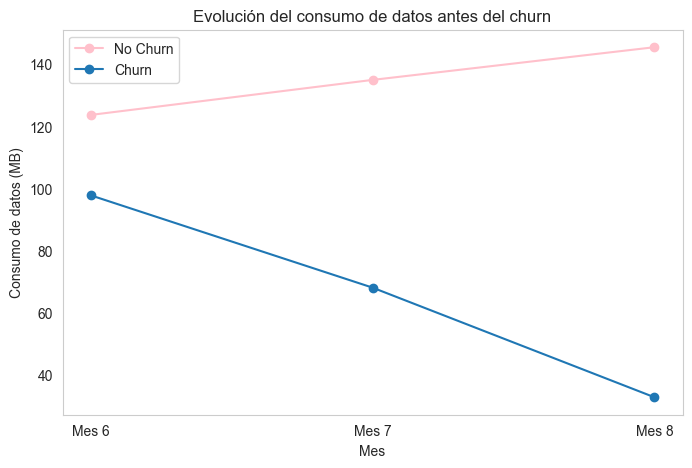

In [224]:
# Promedio de consumo de datos por churn y mes
datos = df_filtrado.groupby('churn')[[
    'vol_3g_mb_6',
    'vol_3g_mb_7',
    'vol_3g_mb_8'
]].mean().T

datos.columns = ['No Churn', 'Churn']
datos.index = ['Mes 6', 'Mes 7', 'Mes 8']

# Plot
plt.figure(figsize=(8,5))

plt.plot(datos.index, datos['No Churn'], marker='o', label='No Churn', color='pink')
plt.plot(datos.index, datos['Churn'], marker='o', label='Churn')

plt.title("Evolución del consumo de datos antes del churn")
plt.xlabel("Mes")
plt.ylabel("Consumo de datos (MB)")
plt.legend()
plt.grid()

plt.show()

#### **insight:** El consumo de datos móviles también presenta una disminución progresiva en los clientes que hacen churn, reforzando que el abandono del servicio está asociado a una caída general en la actividad del usuario.

#### 🔄 Churn vs recargas

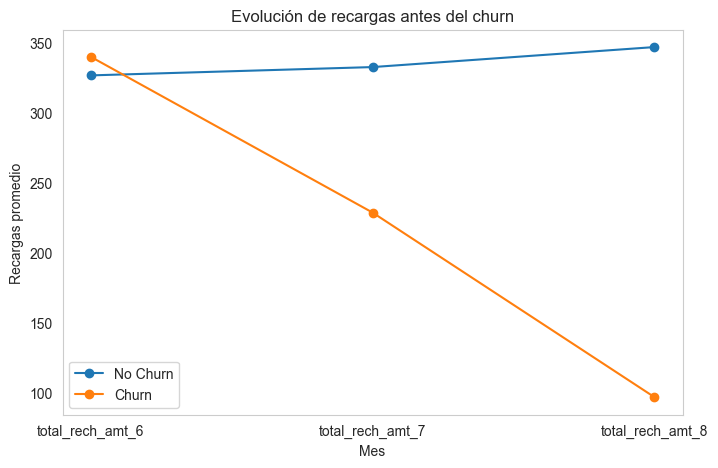

In [225]:

# Promedio de recargas por churn y mes
rechurn = df_filtrado.groupby('churn')[[
    'total_rech_amt_6',
    'total_rech_amt_7',
    'total_rech_amt_8'
]].mean().T

rechurn.columns = ['No Churn', 'Churn']

# Plot
plt.figure(figsize=(8,5))

plt.plot(rechurn.index, rechurn['No Churn'], marker='o', label='No Churn')
plt.plot(rechurn.index, rechurn['Churn'], marker='o', label='Churn')

plt.title("Evolución de recargas antes del churn")
plt.xlabel("Mes")
plt.ylabel("Recargas promedio")
plt.legend()
plt.grid()

plt.show()

#### **insight:** Los clientes en riesgo muestran señales claras de abandono antes de irse, lo que abre oportunidad para estrategias de retención anticipadas.

In [226]:
df_filtrado.groupby('churn')[[
    'total_rech_amt_6',
    'total_rech_amt_7',
    'total_rech_amt_8'
]].mean()

,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8
churn,,,
0,326.324019,332.257785,346.520842
1,339.614758,228.498884,96.872516


#### 📱Churn vs uso de llamadas

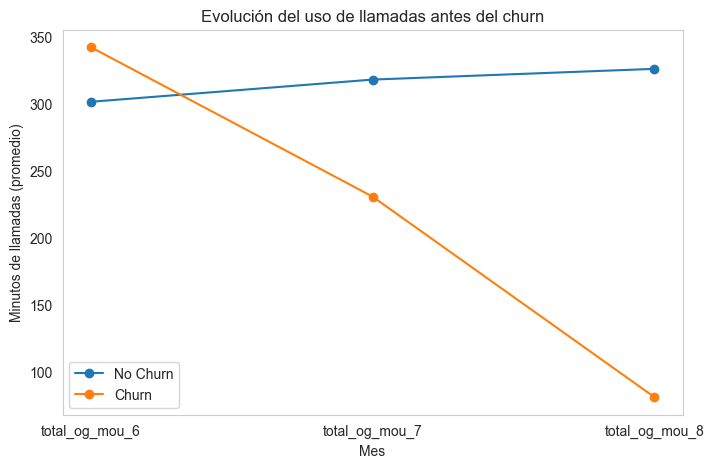

In [227]:
# Promedio de uso de llamadas por churn y mes
uso = df_filtrado.groupby('churn')[[
    'total_og_mou_6',
    'total_og_mou_7',
    'total_og_mou_8'
]].mean().T

uso.columns = ['No Churn', 'Churn']

# Plot
plt.figure(figsize=(8,5))

plt.plot(uso.index, uso['No Churn'], marker='o', label='No Churn')
plt.plot(uso.index, uso['Churn'], marker='o', label='Churn')

plt.title("Evolución del uso de llamadas antes del churn")
plt.xlabel("Mes")
plt.ylabel("Minutos de llamadas (promedio)")
plt.legend()
plt.grid()

plt.show()

#### **insight:** Se observa que los clientes que abandonan el servicio presentan una disminución significativa en el uso de llamadas en los meses previos.

Esto confirma una pérdida progresiva de engagement antes del churn.

#### 🚨 Early Warning Signal

Los clientes churn no son necesariamente de bajo valor, sino que presentan una **caída abrupta en su actividad** antes de abandonar el servicio.

Esto permite detectar señales tempranas de churn.

#### ⏳ Antigüedad vs churn

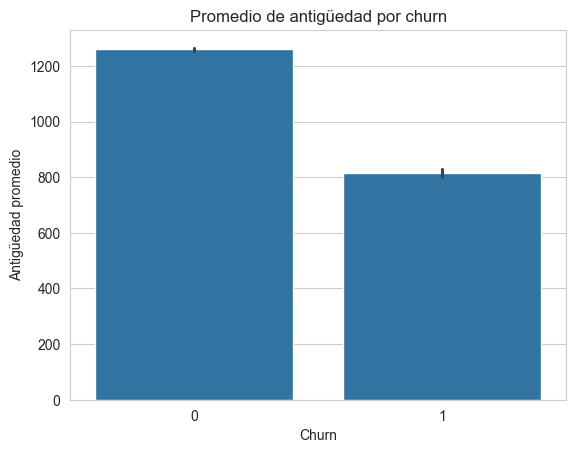

In [228]:
sns.barplot(x='churn', y='aon', data=df_filtrado)

plt.title("Promedio de antigüedad por churn")
plt.xlabel("Churn")
plt.ylabel("Antigüedad promedio")

plt.show()

#### **insight:** La antigüedad del cliente no muestra una diferencia significativa entre clientes activos y churn, lo que indica que el abandono del servicio no está determinado por el tiempo en la empresa, sino por cambios en el comportamiento del usuario.

### ⚙️ Feature Engineering

In [229]:
df_filtrado['caida_rech'] = df_filtrado['total_rech_amt_8'] - df_filtrado['total_rech_amt_6']
df_filtrado.groupby('churn')['caida_rech'].mean()


churn
0     20.196823
1   -242.742242
Name: caida_rech, dtype: float64

In [230]:
# Caída de recargas
df_filtrado['caida_rech'] = df_filtrado['total_rech_amt_8'] - df_filtrado['total_rech_amt_6']
df_filtrado.groupby('churn')['caida_rech'].mean()

churn
0     20.196823
1   -242.742242
Name: caida_rech, dtype: float64

#### **insight - variables clave :** Los clientes que hacen churn presentan una caída promedio de más de 240 unidades en recargas respecto a meses anteriores, mientras que los clientes activos mantienen o incrementan su consumo.

In [231]:
# Riesgo según umbrales
for x in [-50, -100, -150, -200]:
    df_filtrado['riesgo'] = (df_filtrado['caida_rech'] < x).astype(int)
    print(f"Umbral {x}")
    print(df_filtrado.groupby('riesgo')['churn'].mean())
    print("-----")


Umbral -50
riesgo
0    0.043266
1    0.166308
Name: churn, dtype: float64
-----
Umbral -100
riesgo
0    0.045914
1    0.194823
Name: churn, dtype: float64
-----
Umbral -150
riesgo
0    0.052814
1    0.218028
Name: churn, dtype: float64
-----
Umbral -200
riesgo
0    0.058930
1    0.235844
Name: churn, dtype: float64
-----


#### 📊 Evaluación de umbrales

Se observa que:

- Caídas mayores a 150 unidades generan un incremento significativo en la probabilidad de churn
- Este comportamiento puede utilizarse como señal de alerta temprana

In [232]:
df_filtrado['riesgo_final'] = (df_filtrado['caida_rech'] < -150).astype(int)

#### **insight clave:**

Los clientes con una caída superior a 150 unidades en recargas presentan más de **4 veces la probabilidad de churn**.

Esto convierte a `caida_rech` en una variable altamente predictiva.

In [233]:
# Guardar el archivo csv filtrado
df_filtrado.to_csv("../data/clean_churn.csv", index=False)

### 🤖 Modelo predictivo
Se implementa un modelo de regresión logística para predecir churn utilizando variables de comportamiento de meses anteriores.
Debido al desbalance en los datos, se utiliza class_weight="balanced" para mejorar la detección de clientes en riesgo.

In [234]:
features = [
    "total_rech_amt_6", "total_rech_amt_7", "total_rech_amt_8",
    "total_og_mou_6", "total_og_mou_7", "total_og_mou_8",
    "total_ic_mou_6", "total_ic_mou_7", "total_ic_mou_8",
    "vol_2g_mb_6", "vol_2g_mb_7", "vol_2g_mb_8",
    "vol_3g_mb_6", "vol_3g_mb_7", "vol_3g_mb_8",
    "total_rech_num_6", "total_rech_num_7", "total_rech_num_8",
    "aon",
    "caida_rech"
]

X = df_filtrado[features]
y = df_filtrado["churn"]

In [235]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [236]:
# modelo (Logistic Regression)
model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)
model.fit(X_train, y_train)

# Predicción
y_pred = model.predict(X_test)

# evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7643
Recall: 0.8295081967213115
              precision    recall  f1-score   support

           0       0.98      0.76      0.85     18170
           1       0.26      0.83      0.39      1830

    accuracy                           0.76     20000
   macro avg       0.62      0.79      0.62     20000
weighted avg       0.91      0.76      0.81     20000



#### 🔧 Ajuste de threshold
Se ajusta el umbral de decisión del modelo para priorizar la detección de clientes en riesgo (recall), reduciendo el threshold de 0.5 a 0.3.
Esto permite identificar un mayor número de clientes propensos a churn, aunque incrementa los falsos positivos.

In [237]:
# Probabilidades de churn
y_probs = model.predict_proba(X_test)[:,1]

# Ajuste de threshold (más agresivo)
y_pred_custom = (y_probs > 0.3).astype(int)

# Evalución con threshold
print("Accuracy (custom):", accuracy_score(y_test, y_pred_custom))
print("Recall (custom):", recall_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

Accuracy (custom): 0.5739
Recall (custom): 0.9131147540983606
              precision    recall  f1-score   support

           0       0.98      0.54      0.70     18170
           1       0.17      0.91      0.28      1830

    accuracy                           0.57     20000
   macro avg       0.58      0.73      0.49     20000
weighted avg       0.91      0.57      0.66     20000



### 📊 Evaluación del modelo
El modelo logra detectar más del 90% de los clientes que abandonan el servicio.
Sin embargo, esto incrementa los falsos positivos, lo que representa un trade-off entre precisión y recall.


### 🧠 Conclusión

- El churn está asociado a cambios en el comportamiento, no solo a bajo uso  
- La variable `caida_rech` es un indicador clave de riesgo  
- Es posible detectar clientes en riesgo antes de que abandonen  

---

### 💡 Recomendaciones

- Implementar alertas basadas en caídas de actividad  
- Diseñar campañas de retención dirigidas a clientes en riesgo  
- Utilizar el modelo para priorizar acciones comerciales  

---

### 🚀 Impacto

Este análisis permite pasar de un enfoque reactivo a uno proactivo en la gestión de churn.